# Day 6 — Held-out inference and model comparison

This thin notebook compares the recreated Day 4 frozen-embedding baseline with the saved epoch-3 Day 5 classifier. Reusable inference, pairing, metrics, plotting, and persistence remain in `src/transformers_learning/`.

## Resource and leakage boundary

A real run needs the ignored `fine_tuned_model/` artifact, local SST-2 data, and pretrained base-model files. The first run creates the ignored `data/day6_outer_train_frozen_embeddings.npz` cache for the baseline's outer-training rows; later runs reuse it. The outer test rows are never included in that cache, baseline fitting, tuning settings, or checkpoint selection; Day 6 is evaluation only. The integration cells are disabled by default and save only ignored PNG and text artifacts.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
src_path = str(project_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from transformers_learning import (
    DEFAULT_MODEL_NAME,
    adapt_sst2_split,
    build_example_comparison_table,
    compare_five_examples,
    ensure_sst2_train_data,
    evaluate_paired_holdout,
    get_day6_artifact_inputs,
    load_fine_tuned_inference,
    load_model,
    load_tokenizer,
    prepare_comparison_dataset,
    recreate_frozen_baseline,
    save_comparison_results,
    save_paired_confusion_matrices,
)


## Two inference paths

**Fine-tuned path:** tokenization produces tensors `[batch, sequence]` with truncation at 128 tokens. The local sequence classifier returns logits `[batch, 2]`; softmax converts them to probabilities in label order `[0, 1]`, then `argmax` chooses the binary label.

**Frozen baseline path:** the shared base encoder produces contextual first-token features `[batch, hidden_size]`; its weights stay fixed. Logistic Regression maps those features to the same binary labels and probability order. Both paths use `model.eval()` and `torch.no_grad()` during inference: evaluation mode controls layers such as dropout, while no-gradient mode prevents graph construction. Neither operation updates model weights.

In [2]:
RUN_DAY6_INTEGRATION = True

if not RUN_DAY6_INTEGRATION:
    print(
        "Day 6 integration is disabled. Set RUN_DAY6_INTEGRATION = True only "
        "after approving model/data access, runtime, and memory use."
    )
else:
    artifact_inputs = get_day6_artifact_inputs(
        project_root / "fine_tuned_model"
    )
    sst2_train_path = ensure_sst2_train_data(
        project_root / "data" / "SST-2" / "train.tsv"
    )
    source_dataframe = pd.read_csv(sst2_train_path, sep="\t")
    sentiment_dataframe = adapt_sst2_split(source_dataframe)
    comparison_dataset = prepare_comparison_dataset(sentiment_dataframe)

    base_tokenizer = load_tokenizer(DEFAULT_MODEL_NAME)
    base_encoder = load_model(DEFAULT_MODEL_NAME)
    embedding_cache_path = (
        project_root / "data" / "day6_outer_train_frozen_embeddings.npz"
    )
    baseline_setup = recreate_frozen_baseline(
        comparison_dataset,
        base_tokenizer,
        base_encoder,
        embedding_cache_path=embedding_cache_path,
    )
    fine_tuned_setup = load_fine_tuned_inference(artifact_inputs)

    example_comparisons = compare_five_examples(
        fine_tuned_setup,
        baseline_setup,
    )
    display(build_example_comparison_table(example_comparisons))


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

,text,fine_tuned_prediction,fine_tuned_probabilities,baseline_prediction,baseline_probabilities,predictions_agree
0,This movie was absolutely fantastic!,1,"(0.0008133940864354372, 0.9991865754127502)",1,"(0.0014924287419098015, 0.9985075712580902)",True
1,"Terrible, waste of my time.",0,"(0.9992291927337646, 0.0007707689655944705)",0,"(0.997775853210551, 0.0022241467894490432)",True
2,"It was okay, nothing special.",0,"(0.986410915851593, 0.013589096255600452)",0,"(0.5574504880182716, 0.4425495119817285)",True
3,Best film I've seen this year!,1,"(0.00065566849661991, 0.9993442893028259)",1,"(0.00047572639738358014, 0.9995242736026164)",True
4,Boring and too long.,0,"(0.9991187453269958, 0.0008812093292362988)",0,"(0.9996037125664353, 0.00039628743356463764)",True


## Five illustrative examples

The table displays each text, both binary predictions, probabilities, and whether they agree. `It was okay, nothing special.` may sound neutral, but SST-2 has no neutral class: both models still map it to `negative` (0) or `positive` (1). Agreement or confidence for five selected sentences is an illustration, not an accuracy estimate.

## Shared held-out evaluation

The validated SST-2 source order reproduces the deterministic outer 80/20 split (`random_state=42`). Both models predict every shared outer-test row in exactly that order before metrics are calculated. Macro F1 is primary because it gives negative and positive classes equal weight; accuracy is secondary and can hide unequal class behavior. Signed deltas are `fine_tuned − baseline`.

Held-out rows: 13,470
Inference batch size: 16
Starting fine-tuned holdout inference...
Fine-tuned holdout: 16/13,470 (0.1%)
Fine-tuned holdout: 1,024/13,470 (7.6%)
Fine-tuned holdout: 2,048/13,470 (15.2%)
Fine-tuned holdout: 3,072/13,470 (22.8%)
Fine-tuned holdout: 4,096/13,470 (30.4%)
Fine-tuned holdout: 5,120/13,470 (38.0%)
Fine-tuned holdout: 6,144/13,470 (45.6%)
Fine-tuned holdout: 7,168/13,470 (53.2%)
Fine-tuned holdout: 8,192/13,470 (60.8%)
Fine-tuned holdout: 9,216/13,470 (68.4%)
Fine-tuned holdout: 10,240/13,470 (76.0%)
Fine-tuned holdout: 11,264/13,470 (83.6%)
Fine-tuned holdout: 12,288/13,470 (91.2%)
Fine-tuned holdout: 13,312/13,470 (98.8%)
Fine-tuned holdout: 13,470/13,470 (100.0%)
Baseline holdout embeddings: 16/13,470 (0.1%)
Baseline holdout embeddings: 1,024/13,470 (7.6%)
Baseline holdout embeddings: 2,048/13,470 (15.2%)
Baseline holdout embeddings: 3,072/13,470 (22.8%)
Baseline holdout embeddings: 4,096/13,470 (30.4%)
Baseline holdout embeddings: 5,120/13,470 (38.0%)
B

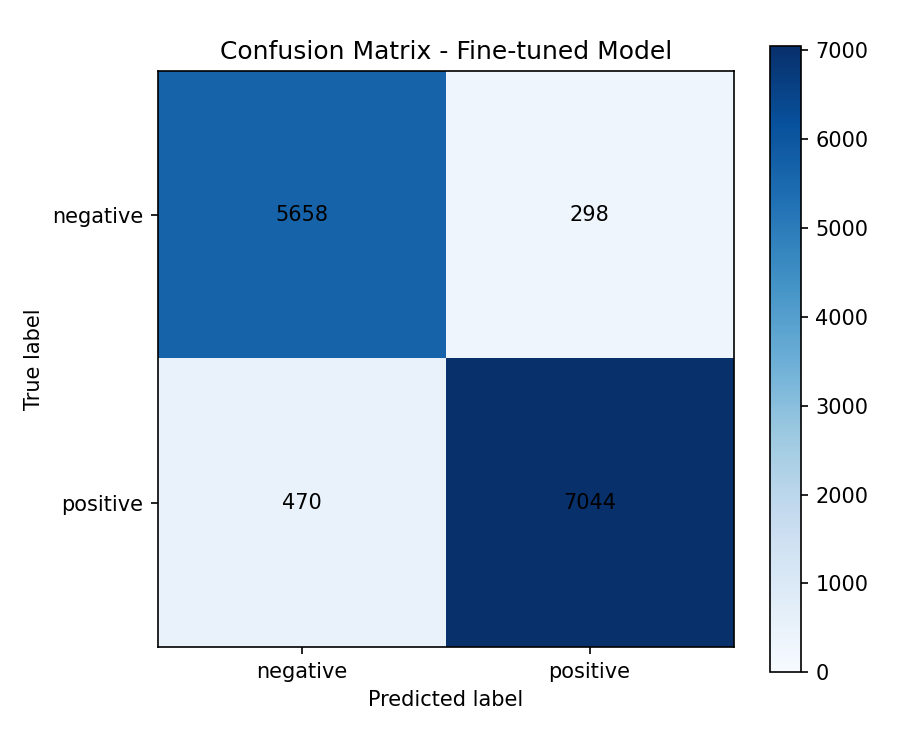

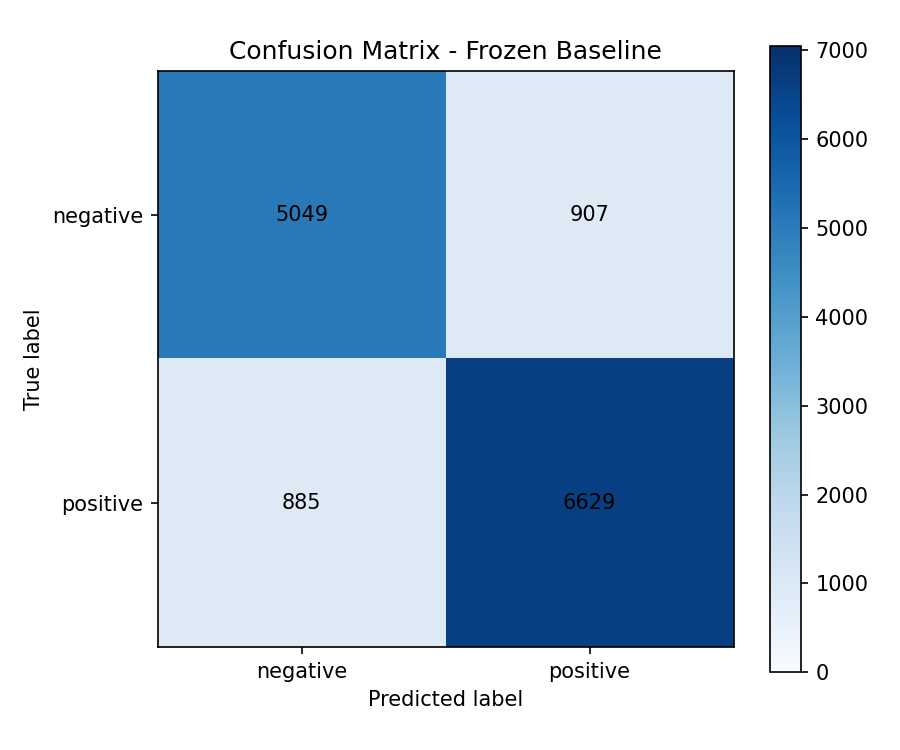

In [3]:
if RUN_DAY6_INTEGRATION:
    holdout_batch_size = 16
    progress_interval = 1_024
    print(f"Held-out rows: {len(comparison_dataset.outer_test):,}")
    print(f"Inference batch size: {holdout_batch_size}")
    print("Starting fine-tuned holdout inference...")
    paired_evaluation = evaluate_paired_holdout(
        comparison_dataset,
        fine_tuned_setup,
        baseline_setup,
        batch_size=holdout_batch_size,
        fine_tuned_progress_callback=lambda completed, total: (
            print(
                f"Fine-tuned holdout: {completed:,}/{total:,} "
                f"({completed / total * 100:.1f}%)"
            )
            if completed == min(holdout_batch_size, total)
            or completed % progress_interval == 0
            or completed == total
            else None
        ),
        baseline_progress_callback=lambda completed, total: (
            print(
                f"Baseline holdout embeddings: {completed:,}/{total:,} "
                f"({completed / total * 100:.1f}%)"
            )
            if completed == min(holdout_batch_size, total)
            or completed % progress_interval == 0
            or completed == total
            else None
        ),
    )
    print("Holdout inference complete; saving metrics and plots...")
    print(
        f"Fine-tuned macro F1: {paired_evaluation.fine_tuned.macro_f1:.4f}; "
        f"accuracy: {paired_evaluation.fine_tuned.accuracy:.4f}"
    )
    print(
        f"Baseline macro F1: {paired_evaluation.baseline.macro_f1:.4f}; "
        f"accuracy: {paired_evaluation.baseline.accuracy:.4f}"
    )
    print(f"Macro F1 delta: {paired_evaluation.macro_f1_delta:+.4f}")
    print(f"Accuracy delta: {paired_evaluation.accuracy_delta:+.4f}")

    matrix_artifacts = save_paired_confusion_matrices(
        paired_evaluation,
        project_root / "confusion_matrix_finetuned.png",
        project_root / "confusion_matrix_baseline.png",
    )
    save_comparison_results(
        paired_evaluation,
        project_root / "comparison_results.txt",
        fine_tuned_model_directory=artifact_inputs.fine_tuned_model_directory,
        fine_tuned_confusion_matrix_path=matrix_artifacts.fine_tuned_path,
        baseline_confusion_matrix_path=matrix_artifacts.baseline_path,
    )
    display(Image(filename=str(matrix_artifacts.fine_tuned_path)))
    display(Image(filename=str(matrix_artifacts.baseline_path)))


## What to remember

- The two models have different internal representations but an aligned external prediction contract: one original text, one binary label, and probabilities `[P(negative), P(positive)]`.
- The shared outer holdout is the leakage boundary. It cannot influence baseline fitting, fine-tuning, checkpoint selection, or settings.
- Probabilities express the model's relative score under this binary setup; they do not prove that a sentiment interpretation is correct or calibrated.
- Confusion matrices show raw error counts with true labels on rows and predicted labels on columns. Detailed inspection of those errors is Day 7 work, not a reason to revise Day 6 models after seeing the holdout.